In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

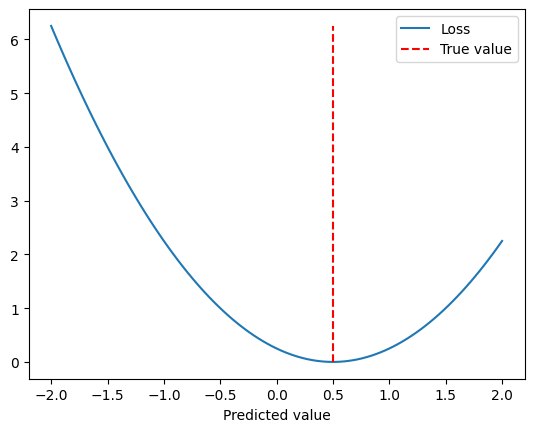

In [2]:
lossfunMSE = nn.MSELoss()

yHat = torch.linspace(-2,2,101)
y = torch.tensor(.5)

L = np.zeros(101)
for i, yy in enumerate(yHat):
    L[i] = lossfunMSE(yy, y)

plt.plot(yHat, L, label='Loss')
plt.plot([y,y],[0,np.max(L)],'r--', label='True value')
plt.xlabel('Predicted value')
plt.legend()
plt.show()

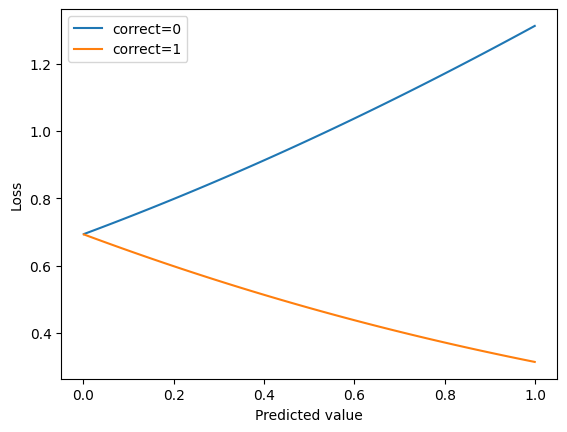

In [4]:
#lossfunBCE = nn.BCELoss()
lossfunBCE = nn.BCEWithLogitsLoss()

yHat = torch.linspace(.001, .999, 101)
y1 = torch.tensor(0.)
y2 = torch.tensor(1.)

L = np.zeros((101,2))
for i, yy in enumerate(yHat):
    L[i,0] = lossfunBCE(yy,y1)
    L[i,1] = lossfunBCE(yy,y2)

plt.plot(yHat,L)
plt.xlabel('Predicted value')
plt.ylabel('Loss')
plt.legend(['correct=0', 'correct=1'])
plt.show()

In [6]:
lossfunCCE = nn.CrossEntropyLoss()

yHat = torch.tensor([[1.,7,3]])

for i in range(3):
    correctAnswer = torch.tensor([i])
    thisloss = lossfunCCE(yHat, correctAnswer).item()
    print(f'Loss when correct answer is {i}: {thisloss}')

Loss when correct answer is 0: 6.020581245422363
Loss when correct answer is 1: 0.020581139251589775
Loss when correct answer is 2: 4.020581245422363


In [7]:
sm = nn.Softmax(dim=1)
yHat_sm = sm(yHat)

for i in range(3):
    correctAnswer = torch.tensor([i])
    thisloss = lossfunCCE(yHat, correctAnswer).item()
    print(f'Loss when correct answer is {i}: {thisloss}')

Loss when correct answer is 0: 6.020581245422363
Loss when correct answer is 1: 0.020581139251589775
Loss when correct answer is 2: 4.020581245422363


In [8]:
sm = nn.LogSoftmax(dim=1)
yHat_logsm = sm(yHat)

print(yHat)
print(yHat_sm)
print(yHat_logsm)

tensor([[1., 7., 3.]])
tensor([[0.0024, 0.9796, 0.0179]])
tensor([[-6.0206, -0.0206, -4.0206]])


## My loss functions

In [10]:
class myLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, y):
        loss = torch.abs(x-y)
        return loss

lfun = myLoss()
lfun(torch.tensor(4), torch.tensor(5.2))

tensor(1.2000)